In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from scipy.special import logsumexp
import pickle
import json
import os
import time
from plotting_functions import plot_method_comparison, plot_gillespie_nmc_comparison
from saving_experiments import save_samples, load_samples, save_samples_summary
from main_code import run_diffusion_experiment, add_gillespie_reverse, add_tau_leap_reverse

GILLESPIE N_MC COMPARISON EXPERIMENT (LIGHTWEIGHT PMF SAVE)

Parameters:
  N (dimensions) = 3
  L (vocab size) = 3
  r (components) = 10
  beta (rate)    = 5.0
  T (term time)  = 3.5
  n_mc values    = [500, 1000]
  checkpoints    = 31

Running experiment with n_mc = 500
Running forward process...
Running Gillespie reverse process...
  Gillespie particle 0/500

⏱️  Timing for n_mc=500:
  Forward sampling:   0.23 seconds (0.00 minutes)
  Gillespie reverse:  0.10 seconds (0.00 minutes)
  Total:              0.33 seconds (0.01 minutes)
  Time per sample:    0.662 ms

💾 Saving samples for n_mc=500...
Computing empirical joint PMFs for lightweight save...
Samples saved (LIGHTWEIGHT - Joint PMFs) to: gillespie_nmc_500.pkl
  - Forward PMFs: 31 checkpoints
  - Reverse PMFs: 1 methods
  - File size: 0.03 MB
  - n_mc: 500, N: 3
  - User metadata: ['N', 'L', 'r', 'beta', 'T', 'n_mc', 'w', 'mu', 'checkpoint_formula', 'n_checkpoints', 'methods', 'timing', 'date', 'notes']
Summary saved to: gillespi

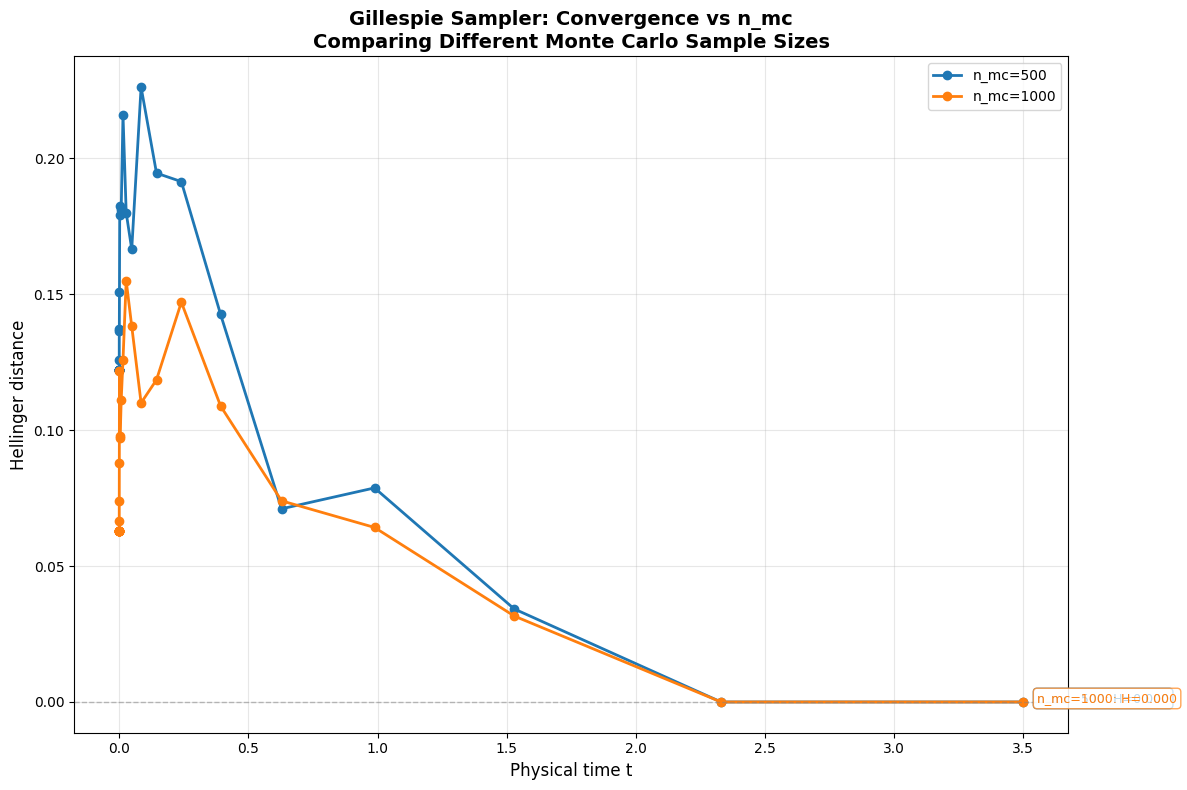


FINAL HELLINGER DISTANCES
  n_mc=    500: H=0.000000
  n_mc=   1000: H=0.000000

TIMING SUMMARY
n_mc         Forward      Gillespie    Total        Per Sample
             (min)        (min)        (min)        (ms)
----------------------------------------------------------------------
500                0.00        0.00        0.01       0.662
1,000              0.01        0.00        0.01       0.602

FILE SIZES (LIGHTWEIGHT PMF SAVES)
  n_mc=    500: 0.03 MB
  n_mc=   1000: 0.03 MB

Creating zoomed plot near t=0...
Plot saved to: gillespie_nmc_comparison_zoom.png


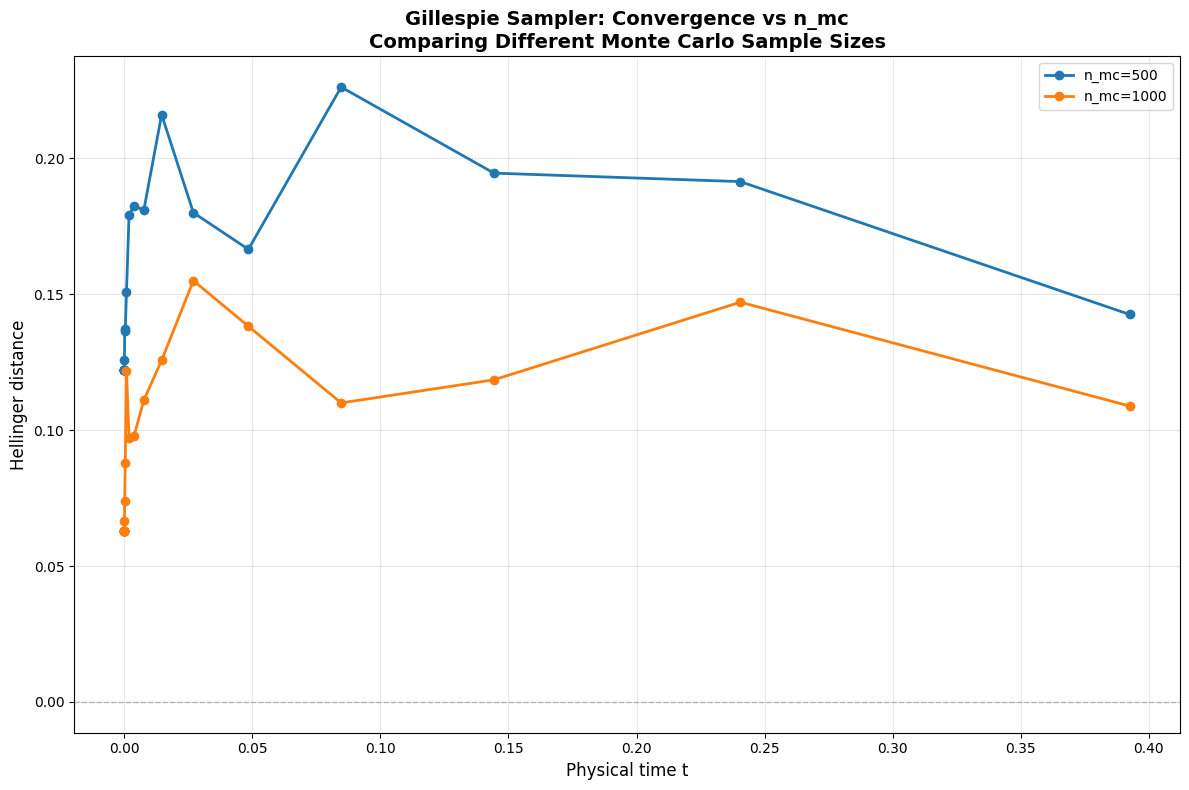


EXPERIMENT COMPLETE!

Generated files:
  - gillespie_nmc_500/
    ├── gillespie_nmc_500.pkl (LIGHTWEIGHT PMF)
    └── gillespie_nmc_500_summary.json
  - gillespie_nmc_1000/
    ├── gillespie_nmc_1000.pkl (LIGHTWEIGHT PMF)
    └── gillespie_nmc_1000_summary.json
  - gillespie_nmc_comparison.png
  - gillespie_nmc_comparison_zoom.png


In [3]:

# ===== Define Parameters =====
N = 3      # Number of dimensions
L = 3      # Vocabulary size per dimension
r = 10     # Number of mixture components

# Create mixture model
w = np.ones(r) / r
mu = np.random.dirichlet([1]*L, size=(r, N))  # Shape: (r, N, L)

# Diffusion parameters
beta = 5.0  # Masking rate
T = 3.5    # Terminal time

# Checkpoint times (physical time from 0 to T)
u = np.linspace(0, 1, 31)
checkpoint_times = T * (u ** 12)  # More checkpoints near t=0

# List of n_mc values to try
n_mc_list = [500, 1000]

print("=" * 70)
print("GILLESPIE N_MC COMPARISON EXPERIMENT (LIGHTWEIGHT PMF SAVE)")
print("=" * 70)
print(f"\nParameters:")
print(f"  N (dimensions) = {N}")
print(f"  L (vocab size) = {L}")
print(f"  r (components) = {r}")
print(f"  beta (rate)    = {beta}")
print(f"  T (term time)  = {T}")
print(f"  n_mc values    = {n_mc_list}")
print(f"  checkpoints    = {len(checkpoint_times)}")

# ===== Run Experiments for Each n_mc =====
samples_dict = {}
filenames = {}
timing_results = {}

for n_mc in n_mc_list:
    print("\n" + "=" * 70)
    print(f"Running experiment with n_mc = {n_mc}")
    print("=" * 70)
    
    # Start total timer
    total_start = time.time()
    
    # Run forward diffusion
    forward_start = time.time()
    samples = run_diffusion_experiment(w, mu, beta, T, n_mc, checkpoint_times)
    forward_time = time.time() - forward_start
    
    # Add Gillespie reverse
    gillespie_start = time.time()
    add_gillespie_reverse(samples, w, mu, beta, T)
    gillespie_time = time.time() - gillespie_start
    
    # Total time
    total_time = time.time() - total_start
    
    # Store timing
    timing_results[n_mc] = {
        'forward': forward_time,
        'gillespie': gillespie_time,
        'total': total_time
    }
    
    # Print timing
    print(f"\n⏱️  Timing for n_mc={n_mc}:")
    print(f"  Forward sampling:   {forward_time:.2f} seconds ({forward_time/60:.2f} minutes)")
    print(f"  Gillespie reverse:  {gillespie_time:.2f} seconds ({gillespie_time/60:.2f} minutes)")
    print(f"  Total:              {total_time:.2f} seconds ({total_time/60:.2f} minutes)")
    print(f"  Time per sample:    {(total_time/n_mc)*1000:.3f} ms")
    
    # Store in dict (keep full samples for verification)
    samples_dict[n_mc] = samples
    
    # Prepare metadata
    experiment_metadata = {
        'N': N,
        'L': L,
        'r': r,
        'beta': beta,
        'T': T,
        'n_mc': n_mc,
        'w': w.tolist(),
        'mu': mu.tolist(),  # ← Save full mu, not just shape
        'checkpoint_formula': 'T * (u ** 12) where u = linspace(0, 1, 31)',
        'n_checkpoints': len(checkpoint_times),
        'methods': samples.list_methods(),
        'timing': timing_results[n_mc],
        'date': '2026-05-23',
        'notes': f'Gillespie baseline with n_mc={n_mc} (LIGHTWEIGHT PMF SAVE)'
    }
    
    # Save samples
    filename = f'gillespie_nmc_{n_mc}'
    filenames[n_mc] = filename
    
    print(f"\n💾 Saving samples for n_mc={n_mc}...")
    # ← KEY CHANGE: Add lightweight=True and L parameter
    save_samples(samples, filename + '.pkl', metadata=experiment_metadata, 
                 lightweight=True, L=L)
    save_samples_summary(samples, filename + '_summary.json', metadata=experiment_metadata)

# ===== Reload and Verify =====
print("\n" + "=" * 70)
print("VERIFICATION: Reloading saved samples and checking integrity")
print("=" * 70)

for n_mc in n_mc_list:
    print(f"\nVerifying n_mc={n_mc}...")
    
    # Load samples (will be PMF dict, not DiffusionSamples object)
    filename = filenames[n_mc]
    loaded_data, loaded_metadata = load_samples(filename + '.pkl')
    
    # Original samples
    original_samples = samples_dict[n_mc]
    
    # Verify it's lightweight format
    assert loaded_data.get('lightweight', False) == True, \
        f"Expected lightweight format for {n_mc}"
    
    # Verify metadata
    assert loaded_data['metadata']['n_mc'] == original_samples.metadata['n_mc'], \
        f"n_mc mismatch for {n_mc}"
    assert loaded_data['metadata']['N'] == original_samples.metadata['N'], \
        f"N mismatch for {n_mc}"
    assert loaded_data['L'] == L, \
        f"L mismatch for {n_mc}"
    
    # Verify times
    assert np.allclose(loaded_data['times'], original_samples.times), \
        f"Times mismatch for {n_mc}"
    
    # Verify joint PMFs sum to 1
    for t in loaded_data['times']:
        forward_pmf = loaded_data['forward_pmfs'][float(t)]
        
        # Check that probabilities sum to 1
        prob_sum = np.sum(forward_pmf['probs'])
        assert np.abs(prob_sum - 1.0) < 1e-6, \
            f"Forward PMF probabilities don't sum to 1 at t={t} for n_mc={n_mc}: sum={prob_sum}"
        
        # Check that all probabilities are non-negative
        assert np.all(forward_pmf['probs'] >= 0), \
            f"Forward PMF has negative probabilities at t={t} for n_mc={n_mc}"
        
        # Check that states and probs have same length
        assert len(forward_pmf['states']) == len(forward_pmf['probs']), \
            f"States and probs length mismatch at t={t} for n_mc={n_mc}"
    
    # Verify reverse PMFs
    for method in loaded_data['reverse_pmfs'].keys():
        for t in loaded_data['times']:
            reverse_pmf = loaded_data['reverse_pmfs'][method][float(t)]
            
            # Check that probabilities sum to 1
            prob_sum = np.sum(reverse_pmf['probs'])
            assert np.abs(prob_sum - 1.0) < 1e-6, \
                f"Reverse PMF probabilities don't sum to 1 for method={method}, t={t}, n_mc={n_mc}: sum={prob_sum}"
            
            # Check that all probabilities are non-negative
            assert np.all(reverse_pmf['probs'] >= 0), \
                f"Reverse PMF has negative probabilities for method={method}, t={t}, n_mc={n_mc}"
            
            # Check that states and probs have same length
            assert len(reverse_pmf['states']) == len(reverse_pmf['probs']), \
                f"States and probs length mismatch for method={method}, t={t}, n_mc={n_mc}"
    
    print(f"  ✓ All checks passed for n_mc={n_mc}")
    print(f"  ✓ Joint PMFs verified (probabilities sum to 1)")

print("\n" + "=" * 70)
print("✓ ALL VERIFICATION CHECKS PASSED!")
print("=" * 70)

# ===== Plot Results =====
print("\n" + "=" * 70)
print("PLOTTING RESULTS")
print("=" * 70)

# Reload as PMF dicts for plotting
samples_dict_pmf = {}
for n_mc in n_mc_list:
    filename = filenames[n_mc]
    data, _ = load_samples(filename + '.pkl')
    samples_dict_pmf[n_mc] = data

# Plot comparison (plotting function handles PMF format)
fig, ax, results = plot_gillespie_nmc_comparison(
    samples_dict_pmf,
    time_start=0.0,
    time_end=T,
    filename='gillespie_nmc_comparison.png',
    show_annotations=True
)

# Print final Hellinger distances
print("\n" + "=" * 70)
print("FINAL HELLINGER DISTANCES")
print("=" * 70)
for n_mc, hellinger in sorted(results.items()):
    print(f"  n_mc={n_mc:7d}: H={hellinger:.6f}")

# Print timing summary
print("\n" + "=" * 70)
print("TIMING SUMMARY")
print("=" * 70)
print(f"{'n_mc':<12} {'Forward':<12} {'Gillespie':<12} {'Total':<12} {'Per Sample'}")
print(f"{'':12} {'(min)':<12} {'(min)':<12} {'(min)':<12} {'(ms)'}")
print("-" * 70)
for n_mc in sorted(timing_results.keys()):
    t = timing_results[n_mc]
    print(f"{n_mc:<12,} {t['forward']/60:>10.2f}  {t['gillespie']/60:>10.2f}  "
          f"{t['total']/60:>10.2f}  {(t['total']/n_mc)*1000:>10.3f}")

# Print file sizes
print("\n" + "=" * 70)
print("FILE SIZES (LIGHTWEIGHT PMF SAVES)")
print("=" * 70)
for n_mc in n_mc_list:
    filename = filenames[n_mc]
    filepath = f"{filename}/{filename}.pkl"
    if os.path.exists(filepath):
        size_mb = os.path.getsize(filepath) / (1024 * 1024)
        print(f"  n_mc={n_mc:7d}: {size_mb:.2f} MB")

# Plot zoomed version near t=0
print("\nCreating zoomed plot near t=0...")
fig_zoom, ax_zoom, _ = plot_gillespie_nmc_comparison(
    samples_dict_pmf,
    time_start=0.0,
    time_end=0.5,
    filename='gillespie_nmc_comparison_zoom.png',
    show_annotations=False
)

print("\n" + "=" * 70)
print("EXPERIMENT COMPLETE!")
print("=" * 70)
print(f"\nGenerated files:")
for n_mc in n_mc_list:
    print(f"  - {filenames[n_mc]}/")
    print(f"    ├── {filenames[n_mc]}.pkl (LIGHTWEIGHT PMF)")
    print(f"    └── {filenames[n_mc]}_summary.json")
print(f"  - gillespie_nmc_comparison.png")
print(f"  - gillespie_nmc_comparison_zoom.png")